# 01 — Initial exploration

**Mock data only.** This notebook is for building/testing the pipeline
(DB → pandas → plots), not for drawing conclusions about vehicle
behavior — any correlations here are artifacts of the mock generator,
not real signal. Swapping in real data later should require no changes
below, just new rows underneath.

In [3]:
import sys, os

# diagnostic — confirm kernel/env are what we expect before doing anything else
print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))
print("ROS-looking paths in sys.path:", [p for p in sys.path if "ros" in p.lower()] or "none")

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: None
ROS-looking paths in sys.path: none


In [4]:
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import query

sns.set_theme(style="darkgrid")

## Connection check

In [5]:
sessions = query("SELECT * FROM sessions ORDER BY started_at;")
sessions

,id,driver_id,started_at,ended_at,notes
0,mock_001,driver_a,2026-07-16 12:37:48.224580+00:00,None,Mock data session
1,live_001,driver_a,2026-07-16 12:37:48.227689+00:00,None,Live OBD session


## Pull raw telemetry

Adjust `session_id` below to whichever session the migrated mock data
actually landed under.

In [6]:
SESSION_ID = "mock_001"

df = query(
    "SELECT * FROM telemetry WHERE session_id = %(session_id)s ORDER BY time;",
    params={"session_id": SESSION_ID},
)
print(df.shape)
df.head()

(64619, 12)


,time,session_id,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z,latitude,longitude
0,2026-07-16 10:48:08.923735+00:00,mock_001,85.2,4394.0,60.7,85.6,48.6,0.467,-0.058,9.838,None,None
1,2026-07-16 10:48:09.024027+00:00,mock_001,85.2,4448.0,59.7,84.2,47.8,0.228,0.237,9.706,None,None
2,2026-07-16 10:48:09.124286+00:00,mock_001,85.3,4492.0,59.1,85.5,47.2,0.498,-0.041,9.801,None,None
3,2026-07-16 10:48:09.224534+00:00,mock_001,85.4,4394.0,58.0,84.2,46.4,-0.322,-0.099,9.762,None,None
4,2026-07-16 10:48:09.324821+00:00,mock_001,85.5,4364.0,55.7,83.5,44.6,0.155,-0.136,9.694,None,None


In [7]:
df.describe()

,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z
count,64597.000000,64597.000000,64597.000000,64597.000000,64597.000000,64597.000000,64597.000000,64597.000000
mean,60.136582,3405.601050,40.018337,84.995096,32.014572,-0.001536,-0.000466,9.810062
std,21.216834,850.267629,14.469744,1.003253,11.575853,0.300888,0.099860,0.049956
min,30.000000,2006.000000,8.700000,80.500000,6.900000,-1.285000,-0.457000,9.602000
25%,38.900000,2557.000000,26.300000,84.300000,21.000000,-0.205000,-0.068000,9.776000
50%,60.300000,3410.000000,39.900000,85.000000,31.900000,-0.002000,0.000000,9.810000
75%,81.400000,4254.000000,53.800000,85.700000,43.000000,0.202000,0.067000,9.844000
max,90.000000,4760.000000,69.900000,89.100000,55.900000,1.198000,0.378000,10.032000


## First-look plots

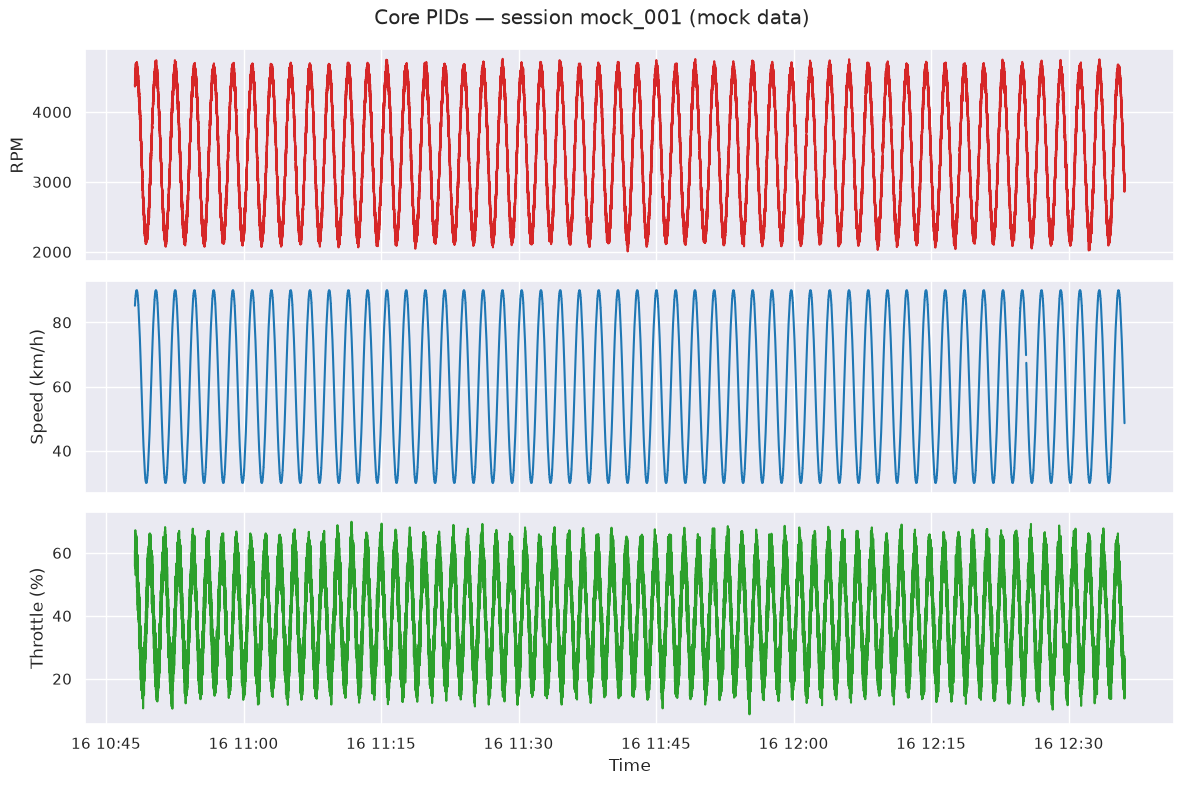

In [8]:
# Core PIDs over time — sanity check that the shapes look sane, not an
# analysis conclusion
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time"], df["rpm"], color="tab:red")
axes[0].set_ylabel("RPM")

axes[1].plot(df["time"], df["speed_kmh"], color="tab:blue")
axes[1].set_ylabel("Speed (km/h)")

axes[2].plot(df["time"], df["throttle_pct"], color="tab:green")
axes[2].set_ylabel("Throttle (%)")
axes[2].set_xlabel("Time")

fig.suptitle(f"Core PIDs — session {SESSION_ID} (mock data)")
fig.tight_layout()

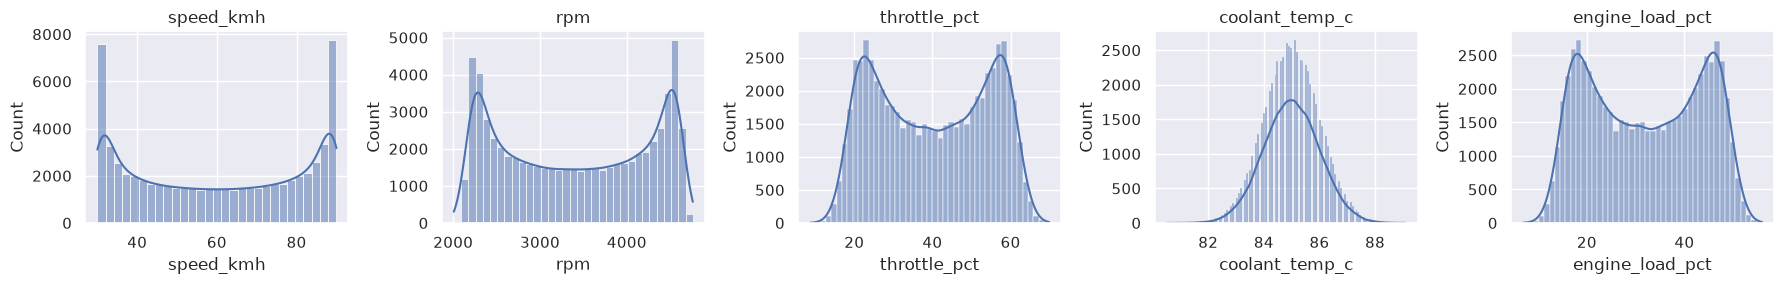

In [9]:
# Distributions — quick shape check across all core PIDs
core_pids = ["speed_kmh", "rpm", "throttle_pct", "coolant_temp_c", "engine_load_pct"]

fig, axes = plt.subplots(1, len(core_pids), figsize=(18, 3))
for ax, col in zip(axes, core_pids):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
fig.tight_layout()

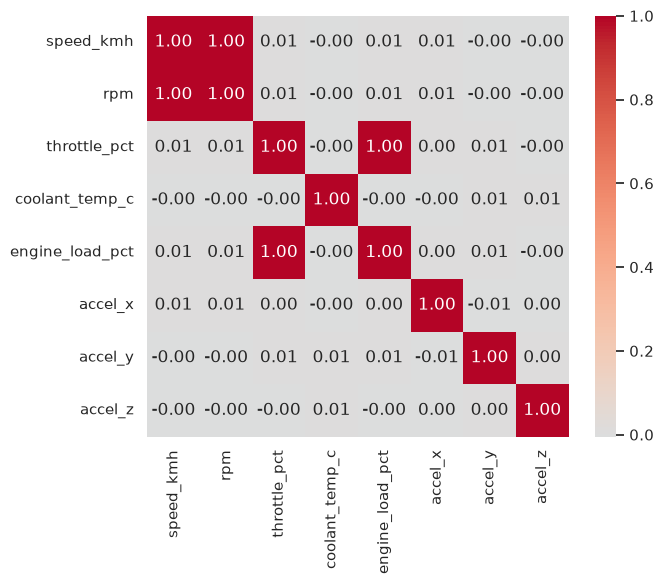

In [10]:
# Correlation matrix — pipeline check only. Do NOT read anything into
# these values while the data is synthetic — correlations here reflect
# the mock generator's own logic, not vehicle behavior.
corr = df[core_pids + ["accel_x", "accel_y", "accel_z"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()